In [2]:
import pandas as pd
import joblib

In [3]:
rf_model = joblib.load("../models/random_forest_model.pkl")
scaler = joblib.load("../models/scaler.pkl")
print("model and scaler loaded")

model and scaler loaded


In [4]:
# New patient data
new_patient = pd.DataFrame({
    "PatientID": [7000],
    "Age": [78],
    "Gender": [1],
    "Ethnicity": [0],
    "EducationLevel": [2],
    "BMI": [27.5],
    "Smoking": [0],
    "AlcoholConsumption": [1],
    "PhysicalActivity": [4],
    "DietQuality": [7],
    "SleepQuality": [6],
    "FamilyHistoryAlzheimers": [1],
    "CardiovascularDisease": [0],
    "Diabetes": [1],
    "Depression": [0],
    "HeadInjury": [0],
    "Hypertension": [1],
    "SystolicBP": [140],
    "DiastolicBP": [85],
    "CholesterolTotal": [210],
    "CholesterolLDL": [130],
    "CholesterolHDL": [50],
    "CholesterolTriglycerides": [170],
    "MMSE": [18],
    "FunctionalAssessment": [4],
    "MemoryComplaints": [1],
    "BehavioralProblems": [1],
    "ADL": [4],
    "Confusion": [1],
    "Disorientation": [1],
    "PersonalityChanges": [1],
    "DifficultyCompletingTasks": [1],
    "Forgetfulness": [1]
})

new_patient

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,7000,78,1,0,2,27.5,0,1,4,7,...,18,4,1,1,4,1,1,1,1,1


In [6]:
new_patient = new_patient.drop(columns=["PatientID"])
new_patient_scaled = scaler.transform(new_patient)
print("Scaled successfully")

Scaled successfully


In [13]:
prediction = rf_model.predict(new_patient)
probability = rf_model.predict_proba(new_patient)
print("Prediction:", prediction[0])
print("Prediction Probability:", probability)

Prediction: 1
Prediction Probability: [[0.1 0.9]]


In [8]:
if prediction[0]==1:
    print("Prediction: Dementia")
else:
    print("Prediction: No Dementia")

Prediction: Dementia


In [10]:
import shap 
explainer = shap.TreeExplainer(rf_model)
print("Explainer created successfully")

Explainer created successfully


In [12]:
new_patient_shap = explainer(new_patient)
print("SHAP values calculated successfully")

SHAP values calculated successfully


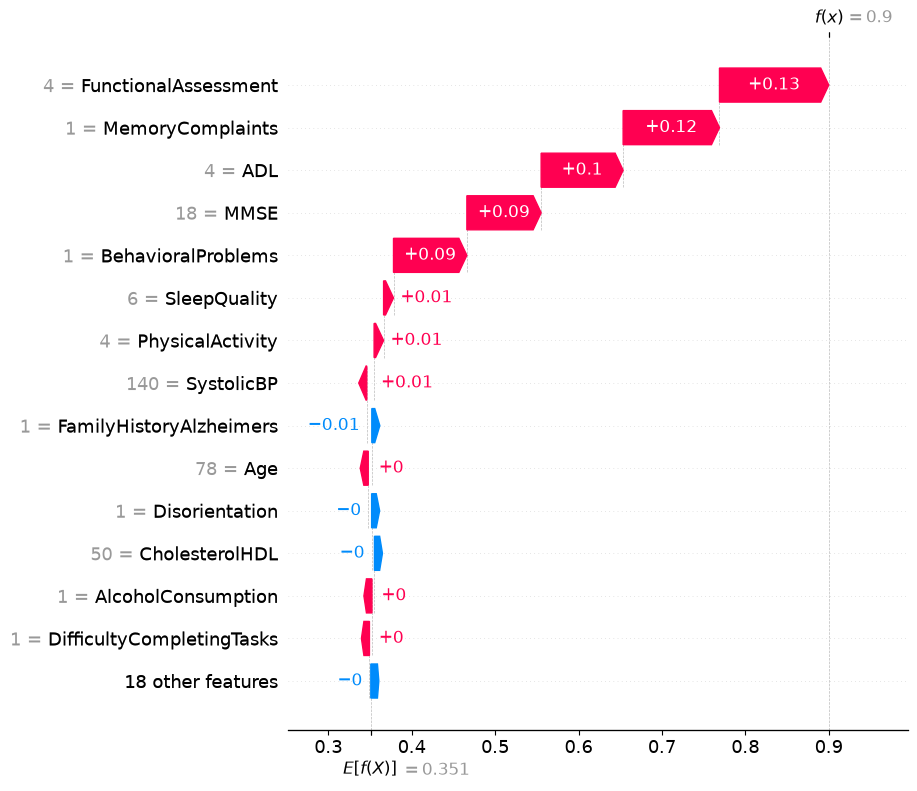

In [15]:
shap.plots.waterfall(new_patient_shap[0, :, 1], max_display=15)

In [16]:
# Display prediction probabilities
print(f"Probability of No Dementia : {probability[0][0]*100:.2f}%")
print(f"Probability of Dementia    : {probability[0][1]*100:.2f}%")

Probability of No Dementia : 10.00%
Probability of Dementia    : 90.00%


In [17]:
print("=" * 60)
print("DEMENTIA PREDICTION SUMMARY")
print("=" * 60)

if prediction[0] == 1:
    print("Prediction : Dementia")
else:
    print("Prediction : No Dementia")

print(f"Confidence : {max(probability[0]) * 100:.2f}%")
print("Model Used : Random Forest")
print("Explanation : SHAP Explainable AI")

DEMENTIA PREDICTION SUMMARY
Prediction : Dementia
Confidence : 90.00%
Model Used : Random Forest
Explanation : SHAP Explainable AI
